In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
df = pd.read_excel("../data/Superstore-final.xlsx")

print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [49]:
customer_count = df['Customer Name'].value_counts()

repeated = (customer_count > 1).sum()
non_repeated = (customer_count == 1).sum()

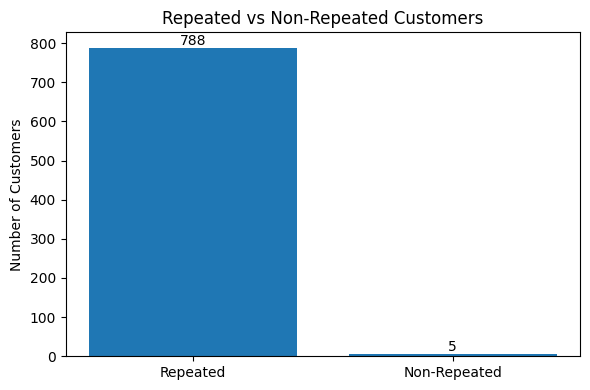

In [68]:
labels = ['Repeated', 'Non-Repeated']
values = [repeated, non_repeated]

plt.figure(figsize=(6,4))

bars = plt.bar(labels, values)

# Show exact count on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

plt.title('Repeated vs Non-Repeated Customers')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

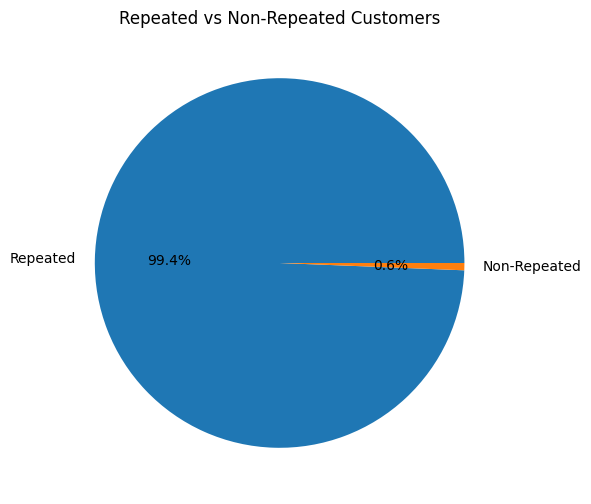

In [51]:
labels = ['Repeated', 'Non-Repeated']
values = [repeated, non_repeated]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title('Repeated vs Non-Repeated Customers')

plt.show()

In [52]:
order_count = df['Order ID'].value_counts()

order_count

Order ID
CA-2017-100111    14
CA-2017-157987    12
US-2016-108504    11
CA-2016-165330    11
CA-2015-131338    10
                  ..
US-2015-151435     1
CA-2017-163566     1
CA-2016-125794     1
CA-2014-110422     1
CA-2017-119914     1
Name: count, Length: 5009, dtype: int64

In [53]:
Total_orders=len(df['Order ID'])
Total_orders

9994

In [54]:
multiple_items = (order_count > 1).sum()
single_items = (order_count == 1).sum()

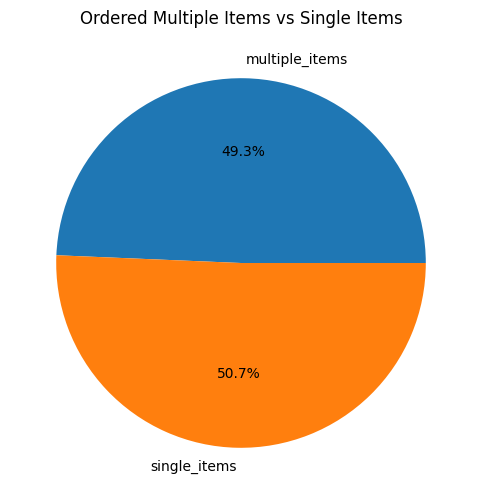

In [55]:
labels = ['multiple_items', 'single_items']
values = [multiple_items, single_items]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title('Ordered Multiple Items vs Single Items')

plt.show()

In [56]:
customer_product = df.groupby(
    ['Customer Name', 'Product Name']
).size().reset_index(name='Order_Count')

reordered_product = customer_product[
    customer_product['Order_Count'] > 1
]
# Customer-Product pairs ordered exactly once
single_order = customer_product[customer_product['Order_Count'] == 1]

customer_reordered_count = len(reordered_product)
customer_single_order_count = len(single_order)

print("Reordered Products:", customer_reordered_count)
print("Single Order Products:", customer_single_order_count)

Reordered Products: 53
Single Order Products: 9888


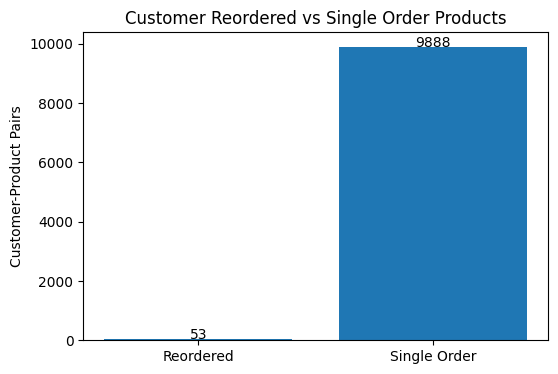

In [57]:
import matplotlib.pyplot as plt

labels = ['Reordered', 'Single Order']
values = [customer_reordered_count, customer_single_order_count]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

# Show exact counts on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center'
    )

plt.title('Customer Reordered vs Single Order Products')
plt.ylabel('Customer-Product Pairs')
plt.show()

In [58]:
product_count = df['Product Name'].value_counts()

unique_products = len(product_count)

reordered_products = (product_count > 1).sum()

single_order_products = (product_count == 1).sum()

print("Unique Products:", unique_products)
print("Reordered Products:", reordered_products)
print("Single Order Products:", single_order_products)

Unique Products: 1850
Reordered Products: 1759
Single Order Products: 91


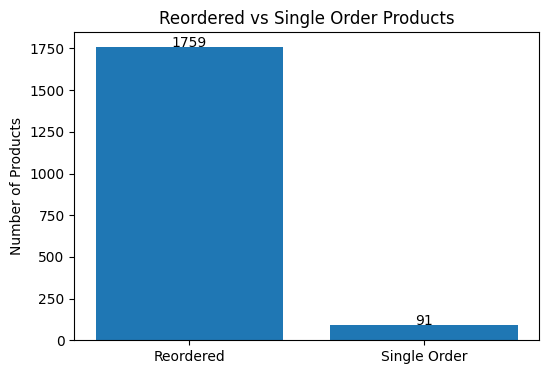

In [59]:
import matplotlib.pyplot as plt

labels = ['Reordered', 'Single Order']
values = [reordered_products, single_order_products]

plt.figure(figsize=(6,4))

bars = plt.bar(labels, values)

# Show counts on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center'
    )

plt.title('Reordered vs Single Order Products')
plt.ylabel('Number of Products')

plt.show()



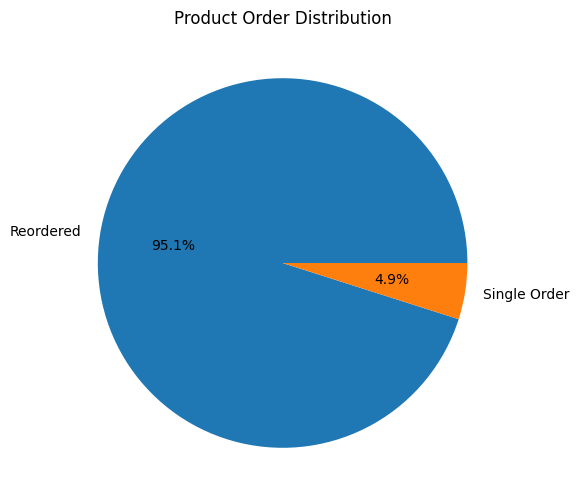

In [60]:
plt.figure(figsize=(6,6))

plt.pie(
    [reordered_products, single_order_products],
    labels=['Reordered', 'Single Order'],
    autopct='%1.1f%%'
)

plt.title('Product Order Distribution')

plt.show()

In [61]:
top_products = df['Product Name'].value_counts().head(10)

print(top_products)

Product Name
Staple envelope                                              48
Easy-staple paper                                            46
Staples                                                      46
Avery Non-Stick Binders                                      20
Staples in misc. colors                                      19
Staple remover                                               18
KI Adjustable-Height Table                                   18
Storex Dura Pro Binders                                      17
Staple-based wall hangings                                   16
Logitech 910-002974 M325 Wireless Mouse for Web Scrolling    15
Name: count, dtype: int64


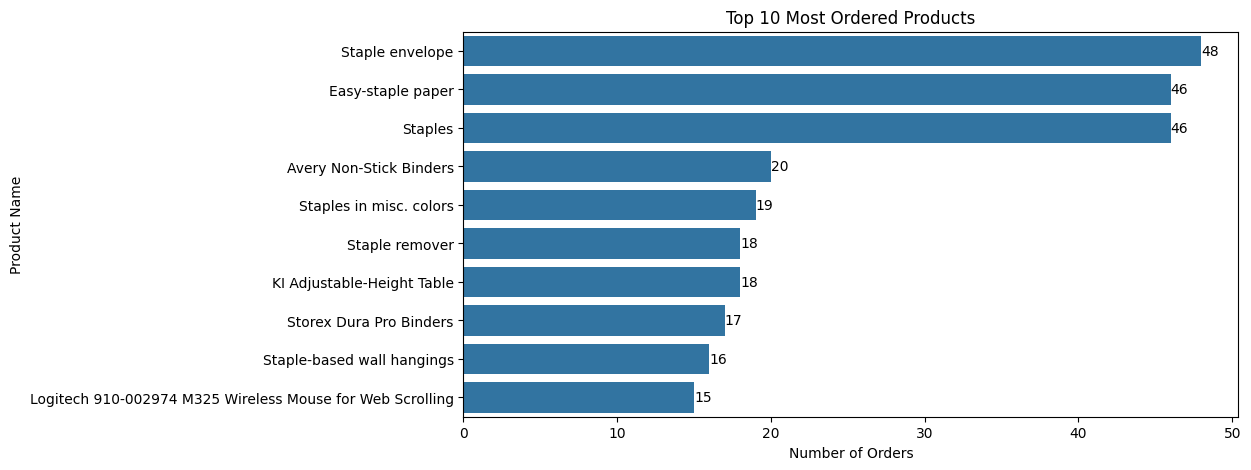

In [62]:
top_products = df['Product Name'].value_counts().head(10)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=top_products.values,
    y=top_products.index
)

# Show exact counts
for i, value in enumerate(top_products.values):
    ax.text(
        value,
        i,
        str(value),
        va='center'
    )

plt.title('Top 10 Most Ordered Products')
plt.xlabel('Number of Orders')
plt.ylabel('Product Name')

plt.show()

In [63]:
region_customer_orders = (
    df.groupby('Region')
      .agg(
          Total_Customers=('Customer ID', 'nunique'),
          Total_Orders=('Order ID', 'nunique')
      )
      .reset_index()
)

print(region_customer_orders)

    Region  Total_Customers  Total_Orders
0  Central              629          1175
1     East              674          1401
2    South              512           822
3     West              686          1611


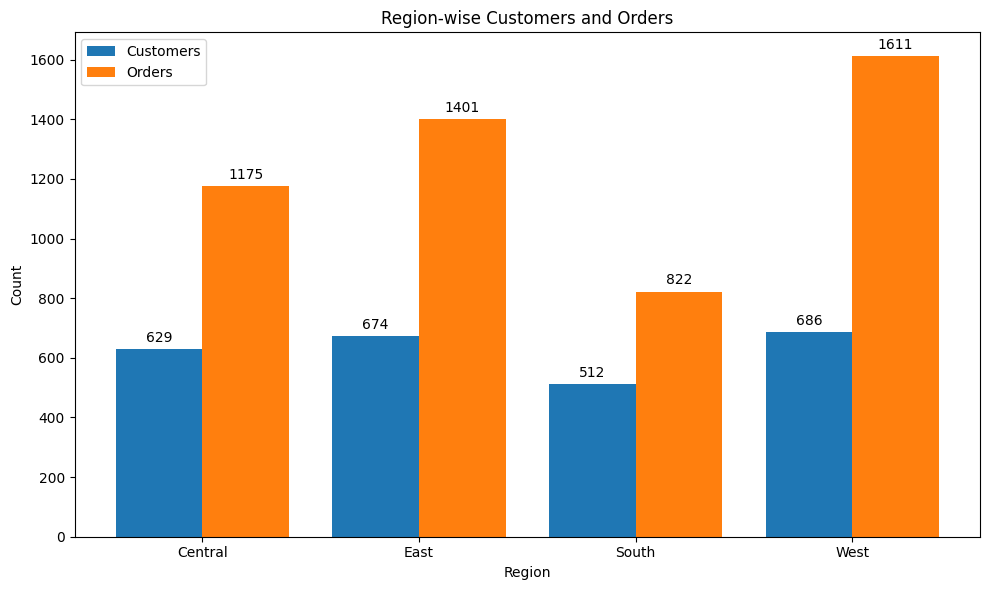

In [64]:
x = np.arange(len(region_customer_orders['Region']))
width = 0.4

plt.figure(figsize=(10,6))

customer_bars = plt.bar(
    x - width/2,
    region_customer_orders['Total_Customers'],
    width,
    label='Customers'
)

order_bars = plt.bar(
    x + width/2,
    region_customer_orders['Total_Orders'],
    width,
    label='Orders'
)

plt.bar_label(customer_bars, padding=3)
plt.bar_label(order_bars, padding=3)

plt.xticks(x, region_customer_orders['Region'])

plt.title('Region-wise Customers and Orders')
plt.xlabel('Region')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

In [65]:
segment_analysis = (
    df.groupby('Segment')
      .agg(
          Orders=('Order ID','nunique'),
          Sales=('Sales','sum')
      )
)

print(segment_analysis)

             Orders         Sales
Segment                          
Consumer       2586  1.161401e+06
Corporate      1514  7.061464e+05
Home Office     909  4.296531e+05


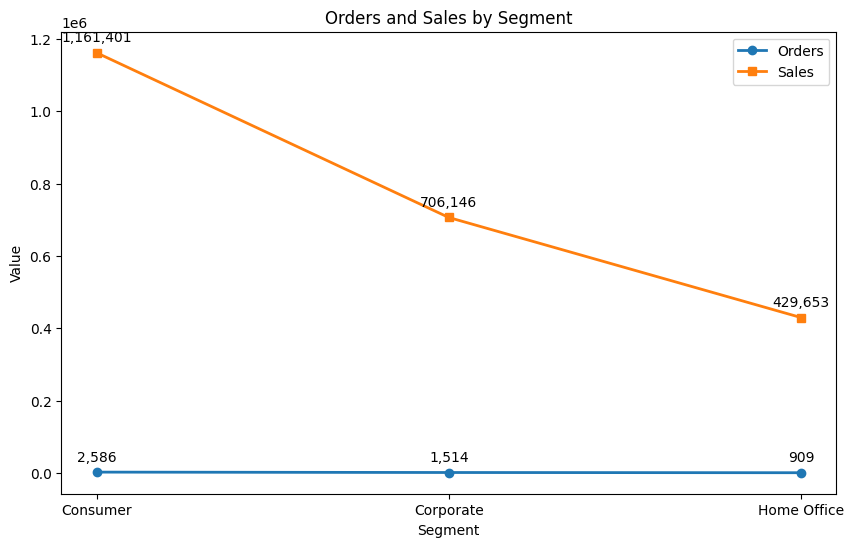

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    segment_analysis.index,
    segment_analysis['Orders'],
    marker='o',
    linewidth=2,
    label='Orders'
)

plt.plot(
    segment_analysis.index,
    segment_analysis['Sales'],
    marker='s',
    linewidth=2,
    label='Sales'
)

# Exact values
for x, y in zip(segment_analysis.index, segment_analysis['Orders']):
    plt.annotate(f'{y:,}', (x, y), xytext=(0, 8),
                 textcoords='offset points', ha='center')

for x, y in zip(segment_analysis.index, segment_analysis['Sales']):
    plt.annotate(f'{y:,.0f}', (x, y), xytext=(0, 8),
                 textcoords='offset points', ha='center')

plt.title('Orders and Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Value')
plt.legend()


plt.show()

In [69]:
segment_customer_orders = (
    df.groupby('Segment')
      .agg(
          Customers=('Customer ID', 'nunique'),
          Orders=('Order ID', 'nunique')
      )
      .reset_index()
)

print(segment_customer_orders)

       Segment  Customers  Orders
0     Consumer        409    2586
1    Corporate        236    1514
2  Home Office        148     909


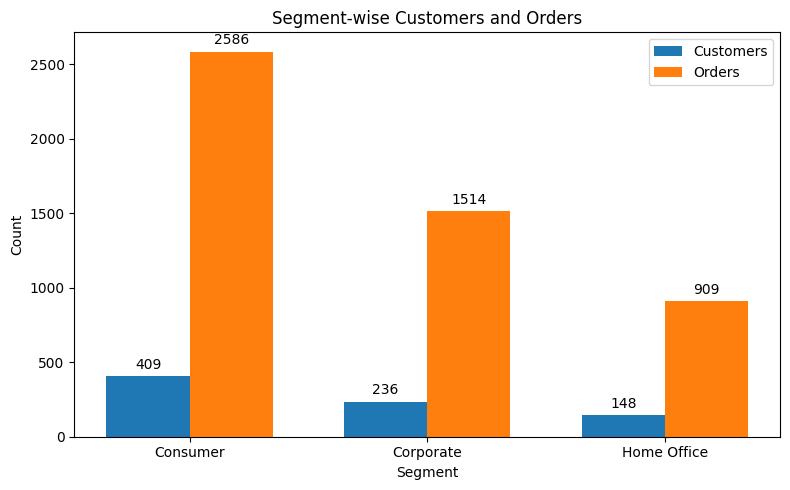

In [70]:
x = np.arange(len(segment_customer_orders['Segment']))
width = 0.35

plt.figure(figsize=(8,5))

customer_bars = plt.bar(
    x - width/2,
    segment_customer_orders['Customers'],
    width,
    label='Customers'
)

order_bars = plt.bar(
    x + width/2,
    segment_customer_orders['Orders'],
    width,
    label='Orders'
)

# Exact values
plt.bar_label(customer_bars, padding=3)
plt.bar_label(order_bars, padding=3)

plt.xticks(x, segment_customer_orders['Segment'])

plt.title('Segment-wise Customers and Orders')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
segment_sales_profit = (
    df.groupby('Segment')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum')
      )
      .reset_index()
)

print(segment_sales_profit)

       Segment         Sales       Profit
0     Consumer  1.161401e+06  134119.2092
1    Corporate  7.061464e+05   91979.1340
2  Home Office  4.296531e+05   60298.6785


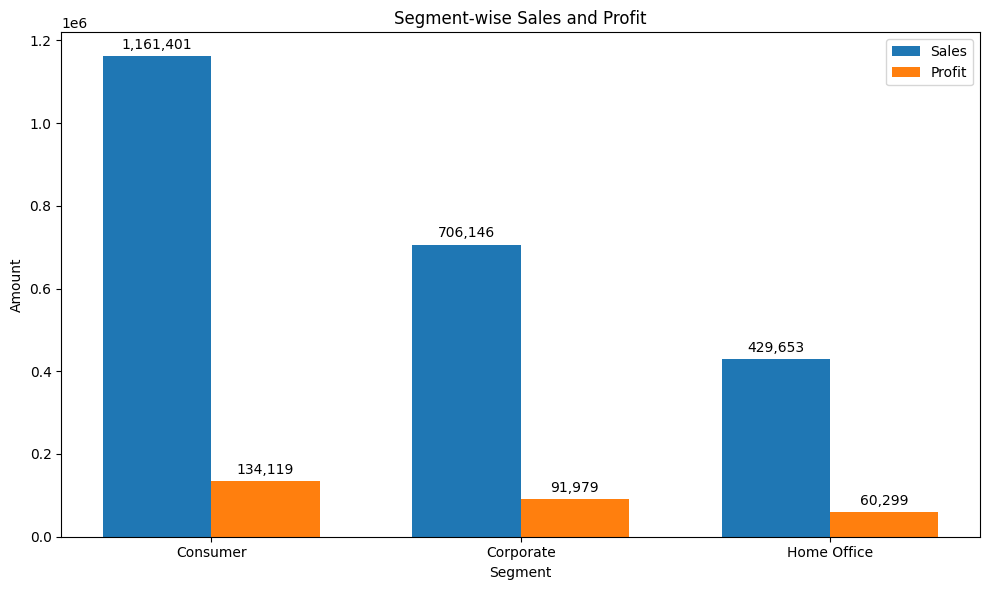

In [72]:
x = np.arange(len(segment_sales_profit['Segment']))
width = 0.35

plt.figure(figsize=(10,6))

sales_bars = plt.bar(
    x - width/2,
    segment_sales_profit['Sales'],
    width,
    label='Sales'
)

profit_bars = plt.bar(
    x + width/2,
    segment_sales_profit['Profit'],
    width,
    label='Profit'
)

# Show exact values
plt.bar_label(
    sales_bars,
    labels=[f'{v:,.0f}' for v in segment_sales_profit['Sales']],
    padding=3
)

plt.bar_label(
    profit_bars,
    labels=[f'{v:,.0f}' for v in segment_sales_profit['Profit']],
    padding=3
)

plt.xticks(x, segment_sales_profit['Segment'])

plt.title('Segment-wise Sales and Profit')
plt.xlabel('Segment')
plt.ylabel('Amount')
plt.legend()

plt.tight_layout()
plt.show()

In [73]:
country_customer_orders = (
    df.groupby('Country')
      .agg(
          Customers=('Customer ID', 'nunique'),
          Orders=('Order ID', 'nunique')
      )
      .reset_index()
      .sort_values(by='Orders', ascending=False)
)

print(country_customer_orders)

         Country  Customers  Orders
0  United States        793    5009


In [78]:
print(df['City'].nunique())

531


In [80]:
print(df['Country'].nunique())

1
